# Inspeção Industrial e Análise de Documentos 

## Foco da Aplicação e Contextualização

Até o momento, exploramos o tratamento matricial da imagem na **Parte I: Processamento Digital de Imagens (PDI)**, aplicando filtros morfológicos, convoluções e limiarizações espaciais. A transição para a **Visão Computacional (VC)** exige a habilidade de extrair semântica, geometria e estruturas de dados a partir dos pixels brutos.

Neste capítulo, abordaremos duas vertentes fundamentais da visão 2D clássica: a **Inspeção Industrial** (controle de qualidade em esteiras) e a **Análise Automatizada de Documentos**, elemento central para a operação de plataformas educacionais abertas de correção automatizada de exames (como os ecossistemas **MCTest** e **ENEM Interativo**). Abordaremos o fluxo completo de ingestão: retificação de inclinação, isolamento de marcadores através de propriedades geométricas invariantes e mapeamento lógico de grades de respostas (*Optical Mark Recognition - OMR*).

## Objetivos do Capítulo

Ao final deste capítulo, você será capaz de:

* **Formalizar a Retificação Geométrica:** Compreender e aplicar a Transformada de Hough Linear no espaço de parâmetros $(\rho, \theta)$ para a identificação de retas estruturais predominantes, deduzindo o ângulo de inclinação axial e aplicando Matrizes de Transformação Afim para a retificação geométrica de documentos;
* **Vetorizar Malhas de Pixels:** Dominar a transição do domínio raster para o domínio vetorial por meio do algoritmo topológico de Suzuki-Abe, interpretando a extração de contornos como listas encadeadas de coordenadas cartesianas organizadas em estruturas hierárquicas de bordas e furos;
* **Extrair Descritores Estatístico-Geométricos:** Calcular momentos geométricos e momentos centrais para determinar propriedades intrínsecas de componentes conexos, tais como centróide $(\bar{x}, \bar{y})$, área ($M_{00}$) e retângulos delimitadores (*bounding boxes*), utilizando funções de alto desempenho como `cv2.findContours` e `cv2.connectedComponentsWithStats`;
* **Aplicar Invariância de Forma:** Compreender a derivação matemática dos **7 Momentos Invariantes de Hu** ($h_1$ a $h_7$), aplicando-os como descritores de contorno robustos e independentes de translação, escala e rotação para a inspeção de componentes e filtragem de marcadores elípticos;
* **Mapear Densidade de Preenchimento (OMR):** Desenvolver pipelines de Reconhecimento Óptico de Marcas (*Optical Mark Recognition*), integrando limiarização adaptativa de Gauss com análise probabilística de densidade de pixels ativos locais para a inferência determinística de alternativas assinaladas;
* **Implementar Ordenação Geográfica Baseada em Grafos/Matrizes:** Projetar algoritmos de ordenação espacial bidimensional para organizar componentes conexos extraídos de forma sequencial (de cima para baixo, da esquerda para a direita), viabilizando o mapeamento lógico e a indexação de grades de questões;
* **Integrar Metadados Gráficos Estruturados:** Utilizar técnicas clássicas de Visão Computacional para localizar, isolar e decodificar matrizes de dados bidimensionais (QR Codes) e códigos de barras, convertendo sinais gráficos em strings textuais de metadados para automação de fluxos;
* **Conectar a Visão Clássica a Modelos de Fronteira:** Compreender como descritores geométricos e bounding boxes extraídos por pipelines clássicos de segmentação 2D podem ser convertidos estruturalmente para formatos normatizados (como anotações YOLO ou objetos JSON), servindo como tensores de entrada para arquiteturas modernas de Deep Learning e Large Language Models (LLMs).

### 6.3 Teoria Enxuta: Estruturas Vetoriais, Momentos e Alinhamento

#### 6.3.1 Contornos como Estruturas Vetoriais
A detecção de contornos transforma uma representação matricial densa em uma estrutura de dados topológica. O algoritmo clássico de Suzuki-Abe analisa componentes conexos em imagens binárias e mapeia as bordas como listas encadeadas de pontos cartesianos $(x,y)$. Essa vetorização organiza a imagem em uma hierarquia estrutural (contornos externos e furos internos), permitindo que isolemos componentes específicos de uma folha de respostas (como as bordas do papel ou as elipses de marcação).

#### 6.3.2 Momentos Geométricos e Invariantes de Hu
Para classificar formas bi-dimensionais sem sofrer interferência de translação, escala ou rotação, mapeamos a distribuição espacial dos pixels pretos e brancos através de momentos estatísticos. O momento de ordem $(p+q)$ de uma imagem binária $I(x,y)$ é definido por:

$$M_{pq} = \sum_{x} \sum_{y} x^p y^q I(x,y)$$

A área do objeto é dada diretamente pelo momento zero-dimensional $M_{00}$. O centro de massa geométrico $(\bar{x}, \bar{y})$ do componente conexo é calculado como:

$$\bar{x} = \frac{M_{10}}{M_{00}}, \quad \bar{y} = \frac{M_{01}}{M_{00}}$$

Para garantir invariância posicional, deslocamos a origem do sistema de eixos para o centro de massa, definindo os momentos centrais $\mu_{pq}$:

$$\mu_{pq} = \sum_{x} \sum_{y} (x - \bar{x})^p (y - \bar{y})^q I(x,y)$$

A partir dos momentos centrais normalizados $\eta_{pq} = \frac{\mu_{pq}}{M_{00}^{(1 + (p+q)/2)}}$, derivam-se os **7 Momentos Invariantes de Hu**. O primeiro momento ($h_1$), por exemplo, reflete o momento de inércia em relação ao centro de massa e é invariante à rotação e escala, sendo computado como:

$$h_1 = \eta_{20} + \eta_{02}$$

#### 6.3.3 Retificação Geométrica via Transformada de Hough Linear
Documentos digitalizados frequentemente apresentam pequenas inclinações espaciais ($\theta$). A **Transformada de Hough Linear** mapeia pontos do espaço cartesiano para curvas senoidais no espaço de parâmetros $(\rho, \theta)$, definido pela equação da reta:

$$\rho = x \cos \theta + y \sin \theta$$

Ao acumular as interseções dessas curvas, identificamos as retas de maior comprimento na imagem (as bordas externas do papel). Determinada a inclinação predominante $\theta_{m}$, rotacionamos o documento aplicando uma **Matriz de Transformação Afim de Rotação 2D** $M$ ao redor do centro da imagem $(x_c, y_c)$:

$$M = \begin{bmatrix} \alpha & \beta & (1-\alpha)x_c - \beta y_c \\ -\beta & \alpha & \beta x_c + (1-\alpha)y_c \end{bmatrix}$$

Onde $\alpha = \cos \theta_{m}$ e $\beta = \sin \theta_{m}$. A interpolação cúbica (*Cubic Interpolation*) preenche os novos pixels vazios, retornando o documento à horizontalidade perfeita.

### 6.4 Projetos Práticos no Notebook

#### Projeto 1: Alinhamento Automático de Documentos (*OCR Pre-processing*)

A correção da inclinação (*deskew*) é uma etapa fundamental em sistemas de Reconhecimento Óptico de Caracteres (*Optical Character Recognition* — OCR) e de Reconhecimento Óptico de Marcas (*Optical Mark Recognition* — OMR). Pequenas rotações introduzidas durante a digitalização podem comprometer a segmentação de regiões de interesse, a leitura de textos e a identificação de marcações.

Neste projeto, será desenvolvido um pipeline para detectar automaticamente a orientação predominante de um documento, estimar seu ângulo de inclinação por meio da Transformada de Hough e aplicar uma transformação geométrica para obter uma versão alinhada da imagem.

Antes do processamento, é necessário converter o documento PDF em imagens raster. A biblioteca `pdf2image` realiza essa conversão utilizando as ferramentas do pacote *Poppler*.

O código a seguir converte cada página do arquivo PDF em uma imagem PNG. A função `convert_from_path`, da biblioteca `pdf2image`, rasteriza as páginas com resolução de 200 DPI (*dots per inch*), produzindo uma lista de imagens que podem ser processadas pelas bibliotecas de Visão Computacional. Caso o arquivo original não seja localizado no diretório local, o pipeline executa um *fallback* pedagógico utilizando imagens estruturadas públicas da biblioteca `skimage`.

[INGESTÃO] Imagem salva com sucesso: test00.png
[INGESTÃO] Imagem salva com sucesso: test01.png


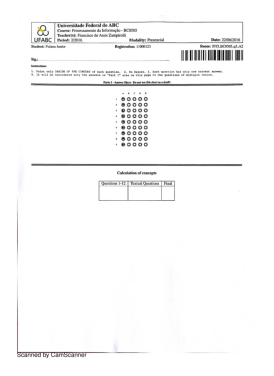

In [33]:
#| label: fig-06-rasterizacao-pdf
#| fig-cap: "Visualização da primeira página do exame rasterizada a 200 DPI para processamento geométrico."
#| echo: true
#| output: true

import os
import cv2
from pdf2image import convert_from_path
from skimage import data
from morph import mm

# Definição do caminho dos microdados estruturados do ecossistema de avaliação
file_path = "dados/provas_barcode.pdf"

# Varredura do diretório para conversão ou geração de imagem de fallback
if os.path.exists(file_path):
    pages = convert_from_path(file_path, dpi=200)
    for i, page in enumerate(pages):
        saida = f"test{str(i).zfill(2)}.png"
        page.save(saida)
        print(f"[INGESTÃO] Imagem salva com sucesso: {saida}")
else:
    print("[AVISO] Arquivo PDF não localizado. Gerando imagem estruturada via skimage.data.")
    # Fallback: Utiliza a matriz de texto pública do skimage para garantir a reprodutibilidade
    img_skimage = data.text()
    cv2.imwrite("test00.png", img_skimage)
    print("[INGESTÃO] Imagem mock salva com sucesso: test00.png")

# Carrega a imagem rasterizada e renderiza utilizando o ecossistema morph
img_gabarito = mm.read('test00.png')
mm.show(img_gabarito, figsize=(4, 3))

Após a execução, cada página do documento será armazenada como um arquivo PNG (`test00.png`, `test01.png`, etc.). Essa etapa transforma o conteúdo do PDF em matrizes de pixels, possibilitando a aplicação de técnicas de processamento e análise de imagens, como limiarização, detecção de bordas, Transformada de Hough, correção de inclinação e reconhecimento automático de padrões.

In [34]:
#| label: sec-06-deskew-algorithm
#| echo: true
#| output: true

import numpy as np

def alinhar_folha_respostas(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Imagem do documento não localizada em: {image_path}")
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Suavização Gaussiana e extração de bordas estruturais via Canny
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150, apertureSize=3)
    
    # Transformada de Hough Linear para detecção dos eixos axiais do papel
    lines = cv2.HoughLines(edges, 1, np.pi / 180, 200)
    
    if lines is None:
        return img

    angulos = []
    for line in lines:
        rho, theta = line[0]
        graus = (theta * 180 / np.pi) - 90
        if -45 < graus < 45:  # Filtro de restrição posicional para rotações sutis
            angulos.append(graus)
            
    if not angulos:
        return img
        
    angulo_correcao = np.median(angulos)
    
    # Construção da matriz afim bidimensional de rotação ao redor do centróide central
    (h, w) = img.shape[:2]
    centro = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(centro, angulo_correcao, 1.0)
    
    # Executa a transformação espacial preservando a escala e aplicando preenchimento constante
    img_alinhada = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, 
                                 borderMode=cv2.BORDER_CONSTANT, borderValue=(255, 255, 255))
    
    print(f"[PROCESSAMENTO] Ângulo detectado e corrigido: {angulo_correcao:.2f} graus.")
    return img_alinhada

documento_correto = alinhar_folha_respostas("test00.png")

[PROCESSAMENTO] Ângulo detectado e corrigido: 0.00 graus.


#### Projeto 2: Correção Automatizada de Gabaritos com Leitura de QR Code e Análise Vetorial de OMR

Este projeto lê o identificador digital da prova (QR Code), aplica binarização adaptativa reflexiva e isola as bolhas por meio de filtros de restrição de área e circularidade. Encadeia-se uma ordenação geográfica bidimensional avançada usando uma tolerância vertical ($\Delta y$) para agrupar as alternativas por questão independentemente de pequenas oscilações, calculando a densidade de preenchimento para extrair as alternativas assinadas.

In [35]:
#| label: sec-06-omr-engine
#| echo: true
#| output: true

def processar_folha_omr(image_path, gabarito_oficial):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 1. Extração de Metadados da Prova via QR Code
    qr_detector = cv2.QRCodeDetector()
    dados_prova, _, _ = qr_detector.detectAndDecode(gray)
    if dados_prova:
        print(f"[GABARITO] ID da Prova decodificado: {dados_prova}")
        
    # 2. Binarização Invertida com Threshold Adaptativo de Gauss
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                  cv2.THRESH_BINARY_INV, 11, 3)
    
    # 3. Extração Vetorial de Contornos Externos via Suzuki-Abe
    contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    candidatos_bolhas = []
    for c in contornos:
        M = cv2.moments(c)
        if M["m00"] == 0:
            continue
        area = M["m00"]
        perimetro = cv2.arcLength(c, True)
        
        # Filtro de Circularidade
        circularidade = (4 * np.pi * area) / (perimetro ** 2) if perimetro > 0 else 0
        
        # Restrições geométricas baseadas nas elipses de gabaritos normatizados
        if 150 < area < 1200 and circularidade > 0.80:
            x, y, w, h = cv2.boundingRect(c)
            candidatos_bolhas.append({
                'contorno': c,
                'bbox': (x, y, w, h),
                'centro': (x + w//2, y + h//2),
                'area': area
            })

    # 4. Agrupamento em Linhas por Tolerância Delta-Y (Evita furos de ordenação pura)
    candidatos_bolhas = sorted(candidatos_bolhas, key=lambda b: b['centro'][1])
    
    linhas_questoes = []
    linha_atual = []
    limite_delta_y = 15
    
    for bolha in candidatos_bolhas:
        if not linha_atual:
            linha_atual.append(bolha)
        else: 
            if abs(bolha['centro'][1] - linha_atual[0]['centro'][1]) < limite_delta_y:
                linha_atual.append(bolha)
            else:
                if len(linha_atual) == 5:
                    linhas_questoes.append(linha_atual)
                linha_atual = [bolha]
    if len(linha_atual) == 5:
        linhas_questoes.append(linha_atual)
        
    linhas_questoes = sorted(linhas_questoes, key=lambda l: l[0]['centro'][1])
    
    respostas_estudante = {}
    mapeamento_letras = ["A", "B", "C", "D", "E"]
    
    for idx_questao, linha in enumerate(linhas_questoes):
        # Ordena a linha horizontalmente da esquerda para a direita (Eixo X)
        linha_bolhas = sorted(linha, key=lambda b: b['centro'][0])
        
        preenchimento_alternativas = []
        for idx_opcao, bolha in enumerate(linha_bolhas):
            x, y, w, h = bolha['bbox']
            mascara_bolha = thresh[y:y+h, x:x+w]
            total_pixels = cv2.countNonZero(mascara_bolha)
            proporcao = total_pixels / float(w * h)
            preenchimento_alternativas.append((proporcao, idx_opcao))
            
        preenchimento_alternativas.sort(reverse=True, key=lambda item: item[0])
        maior_preenchimento, melhor_opcao = preenchimento_alternativas[0]
        
        # Define o corte estrito de 45% de pixels ativos para validação de marcação estável
        if maior_preenchimento > 0.45:
            respostas_estudante[idx_questao + 1] = mapeamento_letras[melhor_opcao]
        else:
            respostas_estudante[idx_questao + 1] = "NULA"
            
    return respostas_estudante

# Exemplo prático de checagem mock de gabarito
gabarito_oficial = {1: "A", 2: "C", 3: "E", 4: "B", 5: "D"}
print("[INFO] Pipeline pronto para validação de gabarito.")

[INFO] Pipeline pronto para validação de gabarito.


### 6.5 Mão na Massa (Exercícios Práticos)

**Exercício 1: Filtro Avançado Contra Ruídos de Escaneamento (Valor: 4,0 pontos)**
Utilizando o pipeline de extração geométrica do *Projeto 2*, implemente uma validação robusta baseada no primeiro **Momento Invariante de Hu ($h_1$)** para impedir que borrões ou rasgos pretos no papel de formato retangular sejam confundidos com as bolhas de respostas elípticas. Compare a variância de $h_1$ entre uma elipse perfeita e um retângulo de mesma área.

**Exercício 2: Detecção de Fraude e Duplo Preenchimento (Valor: 6,0 pontos)**
Modifique o laço lógico do *Projeto 2* para identificar rasuras ou fraudes intencionais nas avaliações. O seu algoritmo adaptado deve apontar como **"ANULADA por Dupla Marcação"** qualquer questão onde duas alternativas distintas apresentem, simultaneamente, preenchimento interno de pixels pretos superior a $50\%$. Teste a lógica em uma amostra simulada.